QUARTA LISTA DE EXERCÍCIOS - CLASSIFICAÇÃO DE DADOS

In [264]:
import pandas as pd 

In [265]:
df = pd.read_csv("diabetes.csv")
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [266]:
target = "Outcome"

In [267]:
print("Valores nulos no dataset:")
display(df.isnull().sum())

Valores nulos no dataset:


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [268]:
print("Distribuição do target no dataset:")
display(df[target].value_counts())

Distribuição do target no dataset:


Outcome
0    500
1    268
Name: count, dtype: int64

<em>QUESTÃO 1</em> - Carregue a base de dados de diabetes e exiba:<br>
-Dimensão X e y<br>
-Nome das features<br>

In [269]:
print(f"Shape: {df.shape}")

features = list(df.columns)
features.remove(target)
print(f"Features: {features}")

Shape: (768, 9)
Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


<em>QUESTÃO 2</em> - Transforme o problema de regressão em classificação binária utilizando a mediana do target:<br>
• Classe 0: abaixo da mediana<br>
• Classe 1: acima da mediana<br>
Mostre a distribuição das classes.<br>

In [270]:
mediana = df[target].median()
print(f"Mediana de {target}: {mediana}")

df["previsao"] = df["Outcome"].apply(lambda x: 0 if x <= mediana else 1)
display(df)

Mediana de Outcome: 0.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,previsao
0,6,148,72,35,0,33.6,0.627,50,1,1
1,1,85,66,29,0,26.6,0.351,31,0,0
2,8,183,64,0,0,23.3,0.672,32,1,1
3,1,89,66,23,94,28.1,0.167,21,0,0
4,0,137,40,35,168,43.1,2.288,33,1,1
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,0
764,2,122,70,27,0,36.8,0.340,27,0,0
765,5,121,72,23,112,26.2,0.245,30,0,0
766,1,126,60,0,0,30.1,0.349,47,1,1


In [271]:
display(df["previsao"].value_counts())

previsao
0    500
1    268
Name: count, dtype: int64

<em>QUESTÃO 3</em> - Divisão dos Dados:<br>
Divida os dados em conjunto de treino e teste (75% / 25%).

In [272]:
from sklearn.model_selection import train_test_split

df_treino, df_teste = train_test_split(df, test_size=0.25, random_state=42)

print("Dataset de treino:")
display(df_treino)

print("Dataset de teste:")
display(df_teste)

X_treino = df_treino[features]
y_treino = df_treino[target]
X_teste = df_teste[features]
y_teste = df_teste[target]


Dataset de treino:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,previsao
357,13,129,0,30,0,39.9,0.569,44,1,1
73,4,129,86,20,270,35.1,0.231,23,0,0
352,3,61,82,28,0,34.4,0.243,46,0,0
497,2,81,72,15,76,30.1,0.547,25,0,0
145,0,102,75,23,0,0.0,0.572,21,0,0
...,...,...,...,...,...,...,...,...,...,...
71,5,139,64,35,140,28.6,0.411,26,0,0
106,1,96,122,0,0,22.4,0.207,27,0,0
270,10,101,86,37,0,45.6,1.136,38,1,1
435,0,141,0,0,0,42.4,0.205,29,1,1


Dataset de teste:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,previsao
668,6,98,58,33,190,34.0,0.430,43,0,0
324,2,112,75,32,0,35.7,0.148,21,0,0
624,2,108,64,0,0,30.8,0.158,21,0,0
690,8,107,80,0,0,24.6,0.856,34,0,0
473,7,136,90,0,0,29.9,0.210,50,0,0
...,...,...,...,...,...,...,...,...,...,...
554,1,84,64,23,115,36.9,0.471,28,0,0
319,6,194,78,0,0,23.5,0.129,59,1,1
594,6,123,72,45,230,33.6,0.733,34,0,0
6,3,78,50,32,88,31.0,0.248,26,1,1


<em>QUESTÃO 4</em> - Aplique normalização nos dados utilizando StandardScaler.

In [273]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_treino = pd.DataFrame(scaler.fit_transform(X_treino), columns=features)
X_teste = pd.DataFrame(scaler.fit_transform(X_teste), columns=features)

print("X_treino normalizado:")
display(X_treino)

print("X_teste normalizado:")
display(X_teste)


X_treino normalizado:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,2.803468,0.259779,-3.780779,0.616770,-0.692052,1.039740,0.296085,0.963521
1,0.078327,0.259779,0.897245,-0.032106,1.633077,0.409454,-0.700876,-0.862956
2,-0.224467,-1.858253,0.679662,0.486995,-0.692052,0.317537,-0.665480,1.137471
3,-0.527260,-1.235302,0.135706,-0.356544,-0.037571,-0.247095,0.231195,-0.689006
4,-1.132847,-0.581204,0.298893,0.162557,-0.692052,-4.199517,0.304934,-1.036906
...,...,...,...,...,...,...,...,...
571,0.381120,0.571254,-0.299459,0.941208,0.513571,-0.444059,-0.169950,-0.602031
572,-0.830054,-0.768089,2.855487,-1.329858,-0.692052,-1.258179,-0.771666,-0.515056
573,1.895088,-0.612352,0.897245,1.070984,-0.692052,1.788206,1.968502,0.441670
574,-1.132847,0.633549,-3.780779,-1.329858,-0.692052,1.368015,-0.777565,-0.341105


X_teste normalizado:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.521349,-0.749736,-0.451769,0.707634,0.996866,0.229089,-0.168835,0.707708
1,-0.609713,-0.304958,0.323506,0.650282,-0.695899,0.426280,-1.090627,-1.061144
2,-0.609713,-0.432037,-0.178142,-1.184965,-0.695899,-0.142093,-1.057939,-1.061144
3,1.086880,-0.463807,0.551528,-1.184965,-0.695899,-0.861259,1.223658,-0.015913
4,0.804114,0.457519,1.007572,-1.184965,-0.695899,-0.246488,-0.887963,1.270525
...,...,...,...,...,...,...,...,...
187,-0.892478,-1.194514,-0.178142,0.134119,0.328669,0.565473,-0.034816,-0.498327
188,0.521349,2.300172,0.460319,-1.184965,-0.695899,-0.988852,-1.152733,1.994146
189,0.521349,0.044511,0.186693,1.395851,1.353237,0.182691,0.821600,-0.015913
190,-0.326947,-1.385134,-0.816604,0.650282,0.088118,-0.118894,-0.763750,-0.659132


<em>QUESTÃO 5</em> - Classificação com KNN <br>
Treine um modelo KNN:<br>
• Utilize K = 5<br>
• Faça previsões no conjunto de teste<br>

In [274]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_treino, y_treino)
predicoes_knn = knn.predict(X_teste)
print(f"Previsão: {predicoes_knn}")

Previsão: [0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 1 1 1 1 1 1 1
 0 0 1 0 1 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0
 0 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 1 1 0 0 0 1 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 1 0 1 0 0 1 1 0 0 0 1 0 1 1 1 1 0 1 0 1 0 0 1 0 0 0 0 1 1 1
 0 0 0 1 1 0 0]


<em>QUESTÃO 6</em> - Avaliação do KNN<br>
Avalie o modelo utilizando:<br>
• Acurácia<br>
• Matriz de confusão<br>

Acurácia do KNN: 0.6822916666666666
Matriz de confusão KNN:


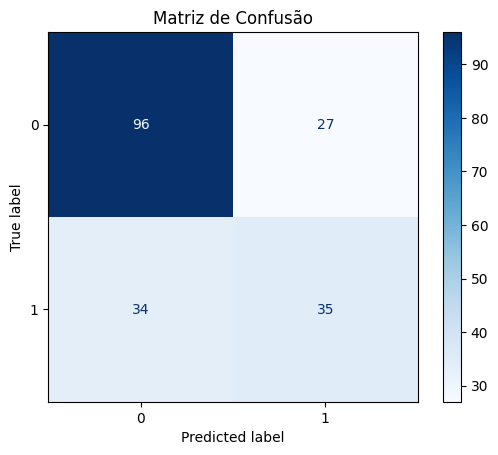

In [275]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acuracia_knn = accuracy_score(y_teste, predicoes_knn)
print(F"Acurácia do KNN: {acuracia_knn}")

matriz_de_confusao_knn = confusion_matrix(y_true=y_teste, y_pred=predicoes_knn)

print("Matriz de confusão KNN:")
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_knn)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão")
plt.show()


<em>QUESTÃO 7</em> - Classificação com SVM<br>
Treine um modelo SVM:<br>
• Utilize kernel linear<br>
• Faça previsões no conjunto de teste

In [276]:
from sklearn.svm import SVC

svm = SVC(kernel="linear")
svm.fit(X_treino, y_treino)

predicoes_svm = svm.predict(X_teste)
print("Predições do SVM:")
print(predicoes_svm)

Predições do SVM:
[0 0 0 0 0 0 0 1 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1
 0 0 1 0 1 0 0 0 1 0 0 0 1 0 1 1 0 0 0 1 0 0 1 1 0 0 0 0 1 0 1 0 1 1 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0 1 0 1 0 0 1 0 0 0
 0 0 1 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 0 0 0 1 0 0 1 1
 0 0 0 1 0 0 0]


<em>QUESTÃO 8</em> - Avaliação do SVM<br>
Avalie o modelo utilizando:<br>
• Acurácia<br>
• Matriz de confusão

Acurácia do SVM: 0.7552083333333334


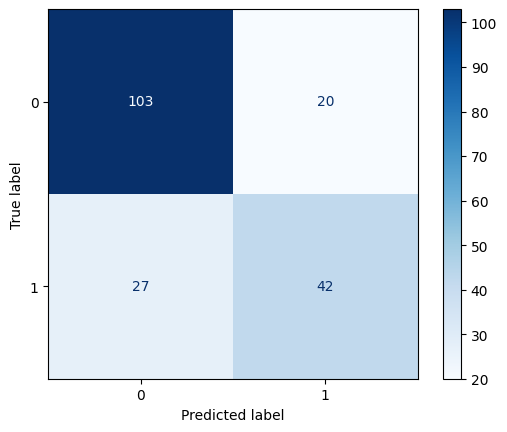

In [277]:
acuracia_svm = accuracy_score(y_true=y_teste, y_pred=predicoes_svm)
print(f"Acurácia do SVM: {acuracia_svm}")

matriz_de_confusao_svm = confusion_matrix(y_true=y_teste, y_pred=predicoes_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_svm)
disp.plot(cmap="Blues")
plt.show()


<em>QUESTÃO 9</em> - Comparação dos Modelos<br>
Compare os resultados dos modelos KNN e SVM:<br>
• Qual modelo teve melhor desempenho?<br>
• Justifique sua resposta

In [278]:
print(f"Acurácia KNN: {acuracia_knn}")
print(f"Acurácia SVM: {acuracia_svm}")

Acurácia KNN: 0.6822916666666666
Acurácia SVM: 0.7552083333333334


Pra mim, o melhor modelo foi o SVM, visto que ele teve uma acurácia maior e, além disso, ao analisar as matrizes de confusão, podemos observar que o SVM se mostrou muito mais eficientes, principalmente em classificar os casos que tinham diagnóstico positivo. O KNN teve 34 falsos negativos e 35 verdadeiros positivos, enquanto o SVM teve 27 falsos negativos e 42 verdadeiros positivos, o que mostra que o SVM aprendeu a identificar os casos realmente positivos melhor que o SVM, o que é algo a se considerar já que o dataset se mostra um pouco desbalanceado.

<em>QUESTÃO 10</em> - Predição de Novo Exemplo<br>
Crie um novo exemplo com 10 atributos e realize a predição utilizando:<br>
• KNN<br>
• SVM

In [279]:
from sklearn.datasets import make_classification

X,y = make_classification(n_samples=1000, n_features=10, random_state=42)

features_df10 = [f"feature_{i+1}" for i in range(10)]
target = "output"
df10 = pd.DataFrame(X, columns=features_df10)
df10[target] = y

df10_treino, df10_teste = train_test_split(df10, train_size=0.7)

X_treino10, y_treino10 = df10_treino[features_df10], df10_treino[target]
X_teste10, y_teste10 = df10_teste[features_df10], df10_teste[target]

In [280]:
knn.fit(X_treino10, y_treino10)

predicoes10_knn = knn.predict(X_teste10)
acuracia10_knn = accuracy_score(y_true=y_teste10, y_pred=predicoes10_knn)

svm.fit(X_treino10, y_treino10)

predicoes10_svm = svm.predict(X_teste10)
acuracai10_svm = accuracy_score(y_true=y_teste10, y_pred=predicoes10_svm)

print(f"Acurácia KNN: {acuracia10_knn}")
print(f"Acurácia SVM: {acuracai10_svm}")


Acurácia KNN: 0.8333333333333334
Acurácia SVM: 0.87


Matriz de confusão do KNN:


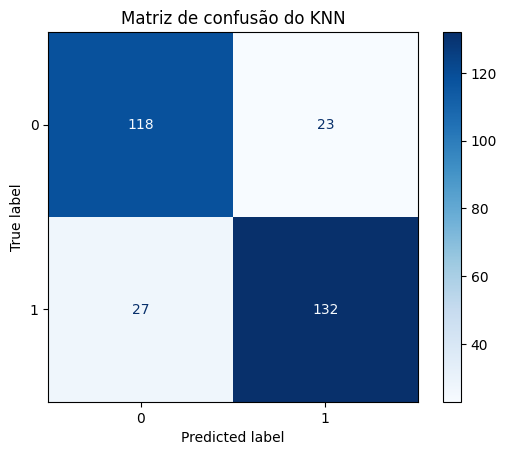

Matriz de confusão do SVM:


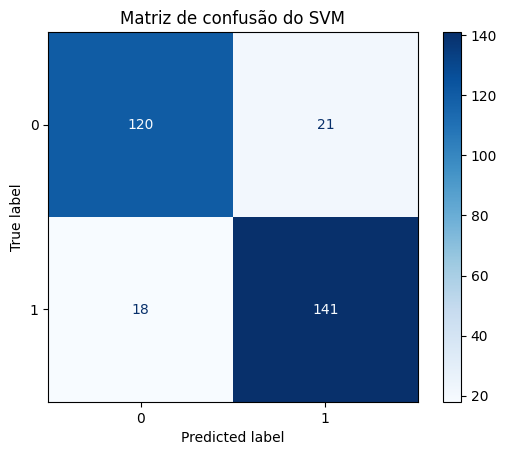

In [281]:
matriz_de_confusao_knn10 = confusion_matrix(y_true=y_teste10, y_pred=predicoes10_knn)
matriz_de_confusao_svm10 = confusion_matrix(y_true=y_teste10, y_pred=predicoes10_svm)

print("Matriz de confusão do KNN:")
disp_knn10 = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_knn10)
disp_knn10.plot(cmap="Blues")
plt.title("Matriz de confusão do KNN")
plt.show()

print("Matriz de confusão do SVM:")
disp_svm10 = ConfusionMatrixDisplay(confusion_matrix=matriz_de_confusao_svm10)
disp_svm10.plot(cmap="Blues")
plt.title("Matriz de confusão do SVM")
plt.show()